In [1]:
import math
import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import DataLoader, Dataset

import numpy as np
import os
from typing import List, Tuple, Optional, Dict, Any, Sequence
from itertools import permutations, combinations
from tqdm import tqdm
import time
import json

In [2]:
import sys
sys.path.append('../')

# Vocabulary and Tokenizer

In [3]:
class QuantumCircuitTokenizer:
    """
    A tokenizer to convert quantum circuits into integer sequences.

    This version is finalized for the QueryAngleTransformer, handles the
    (gate, qubits, params) input format, and includes methods to save and
    load the vocabulary.
    """
    def __init__(
        self,
        max_qubits: int,
        gates_config: Optional[Dict] = None,
        vocab: Optional[Tuple[Dict, Dict]] = None
    ):
        """
        Initializes the tokenizer. Can either build a vocabulary from scratch
        or load a pre-built one.
        """
        self.max_qubits = max_qubits

        if vocab:
            # Load from a pre-built vocabulary
            self.token2id, self.id2token = vocab
            self.gates_config = gates_config if gates_config else self._get_default_config()
        else:
            # Build vocabulary from scratch
            self.gates_config = gates_config if gates_config else self._get_default_config()
            self.token2id, self.id2token = self._build_vocab()

        # Cache special token IDs for faster access
        self.pad_token_id = self.token2id.get(('[PAD]', ()), 0)
        self.unk_token_id = self.token2id.get(('[UNK]', ()), 1)

    def _get_default_config(self) -> Dict:
        """Provides the default gate configuration, excluding [CLS]."""
        return {
            'special_tokens': ['[PAD]', '[UNK]'],
            'gates_1q': ['x', 'z', 'h', 'rx', 'rz'],
            'gates_2q': {
                'cx': {'ordered': True},
                'cz': {'ordered': False}
            }
        }

    def _build_vocab(self) -> Tuple[Dict, Dict]:
        """Builds the vocabulary from the gate configuration."""
        token2id, id2token = {}, {}
        next_id = 0
        for sp in self.gates_config['special_tokens']:
            token = (sp, ())
            token2id[token], id2token[next_id] = next_id, token
            next_id += 1
        for gate in self.gates_config['gates_1q']:
            for q in range(self.max_qubits):
                token = (gate, (q,))
                token2id[token], id2token[next_id] = next_id, token
                next_id += 1
        for gate, props in self.gates_config['gates_2q'].items():
            pairs = permutations(range(self.max_qubits), 2) if props['ordered'] else combinations(range(self.max_qubits), 2)
            for qubits in pairs:
                token = (gate, tuple(qubits))
                token2id[token], id2token[next_id] = next_id, token
                next_id += 1
        return token2id, id2token

    @property
    def vocab_size(self) -> int:
        return len(self.token2id)

    def encode(
        self,
        circuit: Sequence[Tuple[str, Sequence[int], Any]],
        pad_to_len: Optional[int] = None,
        return_tensors: Optional[str] = None
    ) -> Dict[str, Any]:
        """
        Encodes a circuit into a sequence of token IDs and an attention mask.
        Assumes circuit format is (gate, qubits, params).
        """
        ids: List[int] = []
        gate_properties = self.gates_config['gates_2q']

        # This loop correctly unpacks the (gate, qubits, params) tuple
        for gate, qlist, _ in circuit:
            if any(q >= self.max_qubits for q in qlist):
                raise ValueError(f"Qubit index in {qlist} exceeds max_qubits ({self.max_qubits})")

            q_tuple = tuple(qlist)
            if len(q_tuple) == 2 and not gate_properties.get(gate, {}).get('ordered', True):
                q_tuple = tuple(sorted(q_tuple))

            token = (gate, q_tuple)
            ids.append(self.token2id.get(token, self.unk_token_id))

        attention_mask = [1] * len(ids)

        if pad_to_len and len(ids) < pad_to_len:
            pad_needed = pad_to_len - len(ids)
            ids.extend([self.pad_token_id] * pad_needed)
            attention_mask.extend([0] * pad_needed)

        if return_tensors == 'pt':
            return {
                'input_ids': torch.tensor(ids, dtype=torch.long),
                # The key is 'attention_mask' to match the model's forward pass
                'attention_mask': torch.tensor(attention_mask, dtype=torch.bool)
            }

        return {'input_ids': ids, 'attention_mask': [bool(m) for m in attention_mask]}

    def decode(self, ids: Sequence[int], drop_special: bool = True) -> List[Tuple[str, List[int]]]:
        """Decodes a sequence of IDs back into a circuit representation."""
        out = []
        special_tokens = set(self.gates_config['special_tokens'])
        for i in ids:
            if isinstance(i, torch.Tensor): i = i.item()
            gate, q_tuple = self.id2token.get(i, ('[UNK]', ()))
            if drop_special and gate in special_tokens:
                continue
            out.append((gate, list(q_tuple)))
        return out

    def save_vocab(self, vocab_path: str):
        """Saves the vocabulary (token2id map) to a JSON file."""
        # Convert tuple keys to strings for JSON compatibility
        saveable_token2id = {str(k): v for k, v in self.token2id.items()}
        with open(vocab_path, 'w') as f:
            json.dump(saveable_token2id, f)
        print(f"Vocabulary of size {self.vocab_size} saved to {vocab_path}")

    @classmethod
    def from_file(cls, vocab_path: str, max_qubits: int):
        """Loads a tokenizer from a saved vocabulary file."""
        with open(vocab_path, 'r') as f:
            loaded_token2id_str_keys = json.load(f)
            # `eval` is used to convert stringified tuples back to tuples
            token2id = {eval(k): v for k, v in loaded_token2id_str_keys.items()}
            id2token = {v: k for k, v in token2id.items()}
        print(f"Vocabulary of size {len(token2id)} loaded from {vocab_path}")
        return cls(max_qubits=max_qubits, vocab=(token2id, id2token))

    def get_token_id(self, token: Tuple[str, Tuple[int, int]]) -> int:
        """Returns the token ID for a given (gate, qubits) tuple."""
        return self.token2id.get(token, self.unk_token_id)

    def get_token(self, token_id: int) -> Tuple[str, Tuple[int, int]]:
        """Returns the (gate, qubits) tuple for a given token ID."""
        return self.id2token.get(token_id, ('[UNK]', ()))

class QuantumCircuitDataset(Dataset):
    def __init__(self, circuits_data: List[Sequence[Tuple[str, Sequence[int], Sequence[float]]]], tokenizer: QuantumCircuitTokenizer):
        self.circuits_data = circuits_data
        self.tokenizer = tokenizer

    def __len__(self):
        return len(self.circuits_data)

    def __getitem__(self, idx):
        circuit, pqc_params = self.circuits_data[idx]
        # Encode the circuit and return tensors directly
        encoding = self.tokenizer.encode(circuit, return_tensors='pt')
        return encoding, pqc_params


# Transformer Model Architecture

In [4]:
# --------------------
# Step 1: Positional Encoding Module
# --------------------
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=2048):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)  # shape: [1, max_len, d_model]
        self.register_buffer('pe', pe)

    def forward(self, x):
        x = x + self.pe[:, :x.size(1)]
        return x

# --------------------
# Step 2: Transformer Encoder
# --------------------
class TransformerEncoder(nn.Module):
    def __init__(self, vocab_size, d_model, n_heads, d_ff, n_layers, max_len, pad_token_id):
        super().__init__()
        self.token_emb = nn.Embedding(vocab_size, d_model, padding_idx=pad_token_id)
        self.pos_enc = PositionalEncoding(d_model, max_len=max_len)
        
        # ✅ FIX: Use a ModuleList to hold the encoder layers
        self.layers = nn.ModuleList([
            nn.TransformerEncoderLayer(
                d_model=d_model, nhead=n_heads, dim_feedforward=d_ff, batch_first=True
            ) for _ in range(n_layers)
        ])
        
        self.norm = nn.LayerNorm(d_model)

    def forward(self, input_ids, attention_mask):
        x = self.token_emb(input_ids) * math.sqrt(self.token_emb.embedding_dim)
        x = self.pos_enc(x)
        src_key_padding_mask = (attention_mask == 0)
        
        # ✅ FIX: Apply each layer in a loop
        # This bypasses the unimplemented nested tensor optimization on MPS
        for layer in self.layers:
            x = layer(x, src_key_padding_mask=src_key_padding_mask)
            
        return self.norm(x)

# --------------------
# Step 3: Transformer Model with Query Slots
# --------------------
class EncoderWithQuerySlots(nn.Module):
    def __init__(self, vocab_size, pad_token_id, output_shape, d_model=512, 
                 num_model_heads=8, d_ff=2048,
                 num_encoder_layers=6, max_len=2048, dropout=0.1):
        super().__init__()
        self.output_shape = output_shape  # shape: (K, Q, P)
        print("Model Output shape:", self.output_shape)
        self.K, self.Q, self.P = output_shape
        self.num_slots = self.K * self.Q * self.P

        self.encoder = TransformerEncoder(
            vocab_size, d_model, num_model_heads, d_ff, num_encoder_layers, max_len, pad_token_id
        )
        self.block_emb = nn.Embedding(self.K, d_model)
        self.angle_emb = nn.Embedding(self.Q * self.P, d_model)

        self.cross_attn = nn.MultiheadAttention(d_model, num_heads=num_model_heads, dropout=dropout, batch_first=True)
        self.cross_ffn = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Linear(d_model, d_ff),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_ff, d_model),
            nn.LayerNorm(d_model)
        )
        self.out_head = nn.Sequential(
            nn.Linear(d_model, d_model),
            nn.GELU(),
            nn.Linear(d_model, 2),  # Predict (sin, cos)
            # nn.Tanh()
        )

        # Precompute slot indices
        slot_idx = []
        for k in range(self.K):
            for i in range(self.Q * self.P):
                slot_idx.append((k, i))
        self.register_buffer("slot_idx_template", torch.tensor(slot_idx, dtype=torch.long))  # [S, 2]

    def forward(self, input_ids, attention_mask):
        is_batched = input_ids.dim() == 2
        if not is_batched:
            input_ids = input_ids.unsqueeze(0)
            attention_mask = attention_mask.unsqueeze(0)

        B = input_ids.shape[0]
        enc = self.encoder(input_ids, attention_mask)  # [B, L, D]

        # Expand slot index template for each batch
        slot_idx = self.slot_idx_template.unsqueeze(0).repeat(B, 1, 1)  # [B, S, 2]
        block_idx = slot_idx[..., 0].clamp(0, self.K - 1)  # [B, S]
        angle_idx = slot_idx[..., 1].clamp(0, self.Q * self.P - 1)  # [B, S]

        q = self.block_emb(block_idx) + self.angle_emb(angle_idx)  # [B, S, D]
        key_padding_mask = (attention_mask == 0)  # [B, L]

        q2, _ = self.cross_attn(query=q, key=enc, value=enc, key_padding_mask=key_padding_mask)
        q2 = self.cross_ffn(q2)  # [B, S, D]
        out_logits = self.out_head(q2)  # [B, S, 2]
        out = F.normalize(out_logits, p=2, dim=-1, eps=1e-8)
        # Safe normalization
        # norm = torch.norm(out, dim=-1, keepdim=True).clamp(min=1e-6)
        # out = out / norm

        out = out.view(B, self.K, self.Q, self.P, 2)  # reshape to structured layout

        if not is_batched:
            out = out.squeeze(0)  # remove batch dim for single sample

        return out



# Loss Function/s

In [5]:
# --------------------
# Circular Loss Function
# --------------------
def angles_to_sin_cos(theta: torch.Tensor) -> torch.Tensor:
    """Convert angles to (sin, cos) representation."""
    return torch.stack([torch.sin(theta), torch.cos(theta)], dim=-1)

def sin_cos_to_angles(sin_cos: torch.Tensor) -> torch.Tensor:
    """
    Convert (sin, cos) representation back to angles in radians.

    Args:
        sin_cos: Tensor of shape (..., 2) where sin_cos[..., 0] = sin(θ), sin_cos[..., 1] = cos(θ)

    Returns:
        angles: Tensor of shape (...) in radians
    """
    sin_vals = sin_cos[..., 0]
    cos_vals = sin_cos[..., 1]
    angles = torch.atan2(sin_vals, cos_vals)  # returns in range (-π, π]
    return angles


def circular_loss(pred_sin_cos: torch.Tensor, target_sin_cos: torch.Tensor) -> torch.Tensor:
    """
    Computes circular loss: 1 - cos(Δθ) = 1 - dot(pred, target).
    Args:
        pred_sin_cos: [B, S, 2] predicted unit vectors
        target_sin_cos: [B, S, 2] target unit vectors
    Returns:
        Scalar loss averaged over valid slots
    """
    dots = (pred_sin_cos * target_sin_cos).sum(dim=-1)  # [B, S]
    loss_per = 1.0 - dots
    
    loss = loss_per.mean()
    return loss

def circular_mae(pred_sin_cos: torch.Tensor, target_sin_cos: torch.Tensor) -> torch.Tensor:
    """
    Computes circular MAE: mean angular distance (radians) between predicted and target angles.
    """
    cos_delta = (pred_sin_cos * target_sin_cos).sum(dim=-1).clamp(-1.0, 1.0)
    angle_diff = torch.acos(cos_delta)
   
    mae = angle_diff.mean()
    
    return mae


# Training Loop

In [6]:
# # --------------------
# # Step 5: Training Loop
# # --------------------
# def train_step(model, batch, optimizer, scaler=None):
#     model.train()
#     input_ids = batch['input_ids']
#     attention_mask = batch['attention_mask']
#     slot_idx = batch['slot_idx']
#     slot_mask = batch['slot_mask']
#     target_sincos = batch['target_sincos']

#     optimizer.zero_grad(set_to_none=True)
#     with torch.cuda.amp.autocast(enabled=(scaler is not None)):
#         pred_sincos = model(input_ids, attention_mask, slot_idx, slot_mask)
#         loss = circular_loss(pred_sincos, target_sincos, slot_mask)
#         mae = circular_mae(pred_sincos, target_sincos, slot_mask)

#     if scaler:
#         scaler.scale(loss).backward()
#         scaler.unscale_(optimizer)
#         torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
#         scaler.step(optimizer)
#         scaler.update()
#     else:
#         loss.backward()
#         torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
#         optimizer.step()

#     return {'loss': float(loss.item()), 'circular_mae': float(mae.item())}


In [7]:
# =============================================================================
# 1. ROBUST TRAINING STEP FUNCTION
# =============================================================================
def training_step(
    model: nn.Module,
    batch: tuple,
    optimizer: torch.optim.Optimizer,
    scheduler: torch.optim.lr_scheduler._LRScheduler,
    scaler: torch.cuda.amp.GradScaler, # Pass the GradScaler
    device: torch.device,
) -> float:
    """
    A robust training step with mixed-precision, gradient scaling, and clipping.
    """
    model.train()

    # --- Data Handling ---
    encodings, target_angles = batch
    input_ids = encodings['input_ids'].to(device, non_blocking=True)
    attention_mask = encodings['attention_mask'].to(device, non_blocking=True)
    target_angles = target_angles.to(device, non_blocking=True)

    optimizer.zero_grad(set_to_none=True)

    # --- Forward Pass with Mixed Precision ---
    # Autocast automatically chooses float16 or bfloat16 for performance
    with torch.amp.autocast(device_type=device.type, dtype=torch.bfloat16):
        predicted_params = model(input_ids, attention_mask=attention_mask)
        target_sincos = angles_to_sin_cos(target_angles)
        loss = circular_loss(predicted_params, target_sincos)

    # --- Backward Pass with Gradient Scaling ---
    # scaler.scale() multiplies loss by a factor to prevent underflow
    scaler.scale(loss).backward()

    # --- Gradient Clipping (prevents exploding gradients) ---
    # Unscale gradients before clipping to see their true norms
    scaler.unscale_(optimizer)
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

    # --- Optimizer and Scheduler Step ---
    # scaler.step() unsafes the gradients and calls optimizer.step()
    scaler.step(optimizer)
    # Update the scaler for the next iteration
    scaler.update()
    
    scheduler.step()

    return loss.item()

# =============================================================================
# 2. EVALUATION STEP FUNCTION (for validation)
# =============================================================================
def validation_step(
    model: nn.Module,
    batch: tuple,
    device: torch.device
) -> float:
    """Performs a single evaluation step on a batch of validation data."""
    model.eval()

    # --- Data Handling ---
    encodings, target_angles = batch
    input_ids = encodings['input_ids'].to(device, non_blocking=True)
    attention_mask = encodings['attention_mask'].to(device, non_blocking=True)
    target_angles = target_angles.to(device, non_blocking=True)

    # torch.no_grad() is essential for evaluation to prevent memory usage
    with torch.no_grad():
        # Use autocast for consistency and performance
        with torch.amp.autocast(device_type=device.type, dtype=torch.bfloat16):
            predicted_params = model(input_ids, attention_mask=attention_mask)
            loss = circular_loss(predicted_params, angles_to_sin_cos(target_angles))

    return loss.item()

# =============================================================================
# 3. MAIN TRAINING LOOP FUNCTION
# =============================================================================
def train_model(
    model: nn.Module,
    train_dataloader: DataLoader,
    val_dataloader: DataLoader,
    optimizer: torch.optim.Optimizer,
    scheduler: torch.optim.lr_scheduler._LRScheduler,
    epochs: int,
    device: torch.device
):
    """
    The main training loop, now using a GradScaler for stable mixed-precision.
    """
    model.to(device)
    epoch_train_losses, epoch_val_losses = [], []

    # --- Initialize the GradScaler ---
    # Enabled only for CUDA/MPS devices that support it
    scaler = torch.cuda.amp.GradScaler(enabled=(device.type in ['cuda', 'mps']))
    
    for epoch in range(epochs):
        start_time = time.time()

        # --- Training Phase ---
        model.train() # Set model to training mode
        train_loss = 0.0
        for batch in train_dataloader:
            loss = training_step(model, batch, optimizer, scheduler, scaler, device)
            train_loss += loss
        avg_train_loss = train_loss / len(train_dataloader)

        # --- Validation Phase ---
        model.eval() # Set model to evaluation mode
        val_loss = 0.0
        for batch in val_dataloader:
            loss = validation_step(model, batch, device)
            val_loss += loss
        avg_val_loss = val_loss / len(val_dataloader)

        end_time = time.time()
        
        # --- Print Epoch Summary ---
        current_lr = scheduler.get_last_lr()[0]
        print(f"Epoch {epoch + 1:03d}/{epochs} | "
              f"Time: {end_time - start_time:.2f}s | "
              f"Train Loss: {avg_train_loss:.4f} | "
              f"Val Loss: {avg_val_loss:.4f} | "
              f"LR: {current_lr:.6f}")

        epoch_train_losses.append(avg_train_loss)
        epoch_val_losses.append(avg_val_loss)

    return epoch_train_losses, epoch_val_losses

# Constants and Model Shape

In [8]:
# NUM_QUBITS = 5
# NUM_GATES = 20 * 2 # Or 40, if needed.
# GATE_BLOCKS = 10
PQC_GATES = ['rz', 'rx', 'rz']
DATA_PATH = '../nogit/json_data/5q_20g_10blk_data/'
GOOD_DATA_PATH = DATA_PATH + 'good_fidelity/'
BAD_DATA_PATH = DATA_PATH + 'poor_fidelity/'
CONFIG_PATH = DATA_PATH + 'config.json'

with open(CONFIG_PATH, 'r') as f:
    CONFIG = json.load(f)

print(CONFIG)

NUM_QUBITS = CONFIG.get("qubits", 5)[0]
NUM_GATES = CONFIG.get("gates", 20)[0] * 2
GATE_BLOCKS = CONFIG.get("gate_blocks", 10)

BATCH_SIZE = 128
EPOCHS = 1000

WEIGHT_DECAY = 1e-1
LEARNING_RATE = 1e-5
WARMUP_START = 1e-6
COSINE_MIN = 5e-6
PLATEAU_MIN = 1e-8

D_MODEL = 256
NUM_MODEL_HEAD = 2
NUM_ENCODER_LAYERS = 2
NUM_DECODER_LAYERS = 2
DIM_FEEDFORWARD = 1024
DROPOUT = 0.5

TRAIN_FRAC = 0.8
VAL_FRAC = 0.1
TEST_FRAC = 0.1

{'config': 'nogit/json_data/5q_20g_10blk_data/config.json', 'qubit_range': [5], 'gate_range': [20], 'pqc_blocks': 1, 'gate_blocks': 10, 'figure_output': 'nogit/json_data/', 'epochs': 5, 'num_data': 5000, 'num_test': 20, 'seed': '80000', 'gate_dist': None, 'noise_dist': None, 'gpu': False, 'batch': 20, 'force': False, 'redo': False, 'mp_cores': 0, 'qubits': [5], 'gates': [20], 'device': 'cpu'}


In [9]:
raw_data = []
for file in os.listdir(GOOD_DATA_PATH):
    names = file.split('.')
    if file.endswith('.json') and names[0].isdigit() and len(names) == 2:
        with open(os.path.join(GOOD_DATA_PATH, file), 'r') as f:
            file_data = json.load(f)
            raw_data.append(file_data)

len(raw_data)

67433

In [10]:
circuit_data = [(d['base_circuit_tokens'], torch.tensor(d['pqc_params'])) for d in raw_data]

qc_tokenizer = QuantumCircuitTokenizer(max_qubits=NUM_QUBITS)
qc_dataset = QuantumCircuitDataset(circuit_data, qc_tokenizer)

TRAIN_SIZE = int(TRAIN_FRAC * len(qc_dataset))
VAL_SIZE = int(VAL_FRAC * len(qc_dataset))
TEST_SIZE = len(qc_dataset) - TRAIN_SIZE - VAL_SIZE

qc_train_dataset, qc_val_dataset, qc_test_dataset = torch.utils.data.random_split(qc_dataset, [TRAIN_SIZE, VAL_SIZE, TEST_SIZE])
# qc_val_dataset = QuantumCircuitDataset(circuit_data[::VAL_STEP], qc_tokenizer)

qc_train_dataloader = DataLoader(qc_train_dataset, batch_size=BATCH_SIZE, shuffle=True)
qc_val_dataloader = DataLoader(qc_val_dataset, batch_size=BATCH_SIZE, shuffle=True)
qc_test_dataloader = DataLoader(qc_test_dataset, shuffle=True)

print(len(qc_train_dataset), len(qc_train_dataloader))
print(len(qc_val_dataset), len(qc_val_dataloader))
print(len(qc_test_dataset), len(qc_test_dataloader))

53946 422
6743 53
6744 6744


In [11]:
# =============================================================================
# SETUP (Device, Model, Optimizer)
# =============================================================================
device = torch.device("cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu"))
print(f"Using device: {device}")

# NOTE: For DataLoaders, consider using num_workers > 0 and pin_memory=True for faster data loading on CUDA
# qc_train_dataloader = DataLoader(..., num_workers=4, pin_memory=True)

model = EncoderWithQuerySlots(vocab_size=qc_tokenizer.vocab_size, pad_token_id=qc_tokenizer.pad_token_id,
                              output_shape=(NUM_GATES//GATE_BLOCKS, NUM_QUBITS,len(PQC_GATES)),
                              d_model=D_MODEL, num_model_heads=NUM_MODEL_HEAD,
                              num_encoder_layers=NUM_ENCODER_LAYERS,
                              d_ff=DIM_FEEDFORWARD, dropout=DROPOUT)

print(f"Model:\n{model}")

optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

# =============================================================================
# SCHEDULER SETUP (Simplified and Cleaned)
# =============================================================================
# --- Calculate Scheduler Parameters ---
STEPS_PER_EPOCH = len(qc_train_dataloader)
TOTAL_STEPS = EPOCHS * STEPS_PER_EPOCH
WARMUP_EPOCHS = 10
WARMUP_STEPS = WARMUP_EPOCHS * STEPS_PER_EPOCH

# The number of steps for the cosine decay phase is the total steps minus warmup.
COSINE_STEPS = TOTAL_STEPS - WARMUP_STEPS

# --- Create the Schedulers ---
warmup_scheduler = torch.optim.lr_scheduler.LinearLR(
    optimizer,
    start_factor=WARMUP_START / LEARNING_RATE, # A more intuitive start_factor
    total_iters=WARMUP_STEPS
)

cosine_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=COSINE_STEPS,
    eta_min=COSINE_MIN
)

# --- Chain the Schedulers Together ---
# This will apply the warmup scheduler for WARMUP_STEPS, followed by the cosine scheduler.
scheduler = torch.optim.lr_scheduler.SequentialLR(
    optimizer,
    schedulers=[warmup_scheduler, cosine_scheduler],
    milestones=[WARMUP_STEPS]
)

Using device: mps
Model Output shape: (4, 5, 3)
Model:
EncoderWithQuerySlots(
  (encoder): TransformerEncoder(
    (token_emb): Embedding(57, 256, padding_idx=0)
    (pos_enc): PositionalEncoding()
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=256, out_features=256, bias=True)
        )
        (linear1): Linear(in_features=256, out_features=1024, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=1024, out_features=256, bias=True)
        (norm1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
    (norm): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
  )
  (block_emb): Embedding(4, 256)
  (angle_emb): Embedding(15, 

In [12]:
# --- 4. Start Training ---
train_losses, val_losses = train_model(
    model=model,
    train_dataloader=qc_train_dataloader,
    val_dataloader=qc_val_dataloader,
    optimizer=optimizer,
    scheduler=scheduler,  # Pass the scheduler here
    epochs=EPOCHS,
    device=device
)

/var/folders/t2/g8j2h9dd5gj5c2454fz6jz980000gn/T/ipykernel_74746/2760212219.py:97: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(device.type in ['cuda', 'mps']))
/Users/ashutoshtiwari/Desktop/Research-Code/pqc-qec/.venv/lib/python3.13/site-packages/torch/amp/grad_scaler.py:136: UserWarning: torch.cuda.amp.GradScaler is enabled, but CUDA is not available.  Disabling.
  warnings.warn(


Epoch 001/1000 | Time: 38.16s | Train Loss: 1.0003 | Val Loss: 1.0008 | LR: 0.000002
Epoch 002/1000 | Time: 35.03s | Train Loss: 1.0002 | Val Loss: 1.0005 | LR: 0.000003
Epoch 003/1000 | Time: 35.58s | Train Loss: 0.9997 | Val Loss: 1.0008 | LR: 0.000004
Epoch 004/1000 | Time: 37.35s | Train Loss: 0.9999 | Val Loss: 0.9996 | LR: 0.000005
Epoch 005/1000 | Time: 36.46s | Train Loss: 0.9991 | Val Loss: 0.9994 | LR: 0.000006
Epoch 006/1000 | Time: 35.36s | Train Loss: 0.9992 | Val Loss: 1.0003 | LR: 0.000006
Epoch 007/1000 | Time: 35.17s | Train Loss: 0.9992 | Val Loss: 1.0000 | LR: 0.000007
Epoch 008/1000 | Time: 34.69s | Train Loss: 0.9987 | Val Loss: 1.0001 | LR: 0.000008
Epoch 009/1000 | Time: 34.80s | Train Loss: 0.9983 | Val Loss: 0.9997 | LR: 0.000009


/Users/ashutoshtiwari/Desktop/Research-Code/pqc-qec/.venv/lib/python3.13/site-packages/torch/optim/lr_scheduler.py:209: UserWarning: The epoch parameter in `scheduler.step()` was not necessary and is being deprecated where possible. Please use `scheduler.step()` to step the scheduler. During the deprecation, if epoch is different from None, the closed form is used instead of the new chainable form, where available. Please open an issue if you are unable to replicate your use case: https://github.com/pytorch/pytorch/issues/new/choose.
  warnings.warn(EPOCH_DEPRECATION_WARNING, UserWarning)


Epoch 010/1000 | Time: 35.85s | Train Loss: 0.9983 | Val Loss: 1.0000 | LR: 0.000010
Epoch 011/1000 | Time: 35.38s | Train Loss: 0.9981 | Val Loss: 0.9999 | LR: 0.000010
Epoch 012/1000 | Time: 35.05s | Train Loss: 0.9974 | Val Loss: 1.0013 | LR: 0.000010
Epoch 013/1000 | Time: 35.10s | Train Loss: 0.9974 | Val Loss: 1.0004 | LR: 0.000010
Epoch 014/1000 | Time: 34.75s | Train Loss: 0.9981 | Val Loss: 1.0003 | LR: 0.000010
Epoch 015/1000 | Time: 35.58s | Train Loss: 0.9969 | Val Loss: 1.0003 | LR: 0.000010
Epoch 016/1000 | Time: 35.45s | Train Loss: 0.9966 | Val Loss: 0.9990 | LR: 0.000010
Epoch 017/1000 | Time: 35.96s | Train Loss: 0.9962 | Val Loss: 1.0008 | LR: 0.000010
Epoch 018/1000 | Time: 35.15s | Train Loss: 0.9968 | Val Loss: 0.9987 | LR: 0.000010
Epoch 019/1000 | Time: 34.66s | Train Loss: 0.9961 | Val Loss: 0.9998 | LR: 0.000010
Epoch 020/1000 | Time: 34.96s | Train Loss: 0.9963 | Val Loss: 1.0003 | LR: 0.000010
Epoch 021/1000 | Time: 35.44s | Train Loss: 0.9956 | Val Loss: 0.

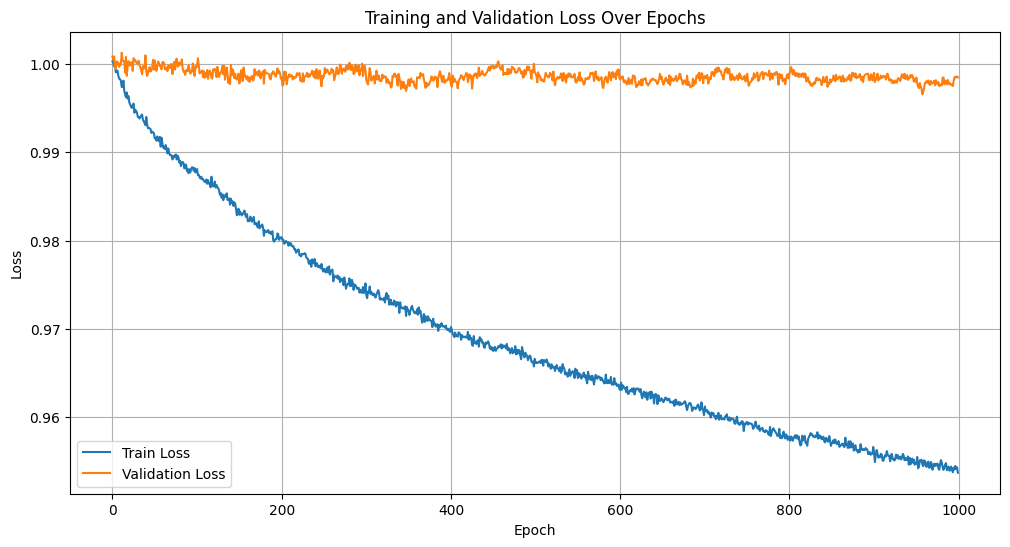

In [13]:
import matplotlib.pyplot as plt
from datetime import datetime

plt.figure(figsize=(12, 6))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss Over Epochs')
plt.legend()
plt.grid()
if train_losses[-1] < 0.05:  # Check if the final train loss is low
    model_name = f"{model._get_name()}_{datetime.now().strftime('%Y%m%d_%H%M')}"
    model_file_path = f"../pytorch_checkpoints/{model_name}.pth"
    # os.makedirs(os.path.dirname(model_file_path), exist_ok=True)
    torch.save(model.state_dict(), model_file_path)
    print(f"Model saved to {model_file_path}")
    plt.savefig(f'../plots/loss_curves/{model_name}_loss.png')

plt.show()

# Testing Model with Zero State

In [14]:
def interleave_tensor_pqc_in_circuit(base_ops:list, qubits:int, blocks:int, pqc_gates:list, params:list):
    """Interleave PQC operations into the base circuit."""
    interleaved_circuit = []
    # print(params.shape)
    for i, op in enumerate(base_ops):
        # print(i, op)
        interleaved_circuit.append(op)
        if (i + 1) % blocks == 0:
            k = (i + 1) // blocks - 1
            # print(f"Interleaving PQC operations for block {k}")
            for q in range(qubits):
                for j, g in enumerate(pqc_gates):
                    # print(g, q, (k,q,j), params[k, q, j])
                    interleaved_circuit.append((g, [q], params[k, q, j].detach().numpy()))
    return interleaved_circuit

In [15]:
from pqcqec.noise.simple_noise import PennylaneNoisyGates
from pqcqec.simulate.simulate import run_circuit_with_noise_model
from pqcqec.training.jax_loss_functions import jax_pure_state_fidelity

import jax.numpy as jnp

noise_model = PennylaneNoisyGates()
# NUM_QUBITS = 5
ZERO_STATE = jnp.zeros((2 ** NUM_QUBITS,), dtype=jnp.complex64).at[0].set(1.0)

circuit = raw_data[0]['base_circuit_tokens']  # Example circuit
pqc_circuit = raw_data[0]['pqc_circuit_tokens']  # Example PQC circuit

In [16]:
model.eval()  # Set the model to evaluation mode
test_fid_model = []
test_fid_default = []
for i, data in enumerate(qc_test_dataloader):

    tokens, params = data
    circuit_ops = qc_tokenizer.decode(tokens['input_ids'][0])
    circuit_ops = [(op[0], op[1], []) for op in circuit_ops]  # Add params placeholder from the circuit ops
    pqc_circuit = interleave_tensor_pqc_in_circuit(circuit_ops, NUM_QUBITS, GATE_BLOCKS, PQC_GATES, params[0])

    input_ids = tokens['input_ids'].to(device)
    attention_mask = tokens['attention_mask'].to(device)

    pred_theta = model(input_ids, attention_mask=attention_mask)[0]
    pred_theta = sin_cos_to_angles(pred_theta).to('cpu')
    # print(pred_theta)
    # pred_theta = decode_von_mises_parameters(pred_params)['mean_angle_rad'].to(torch.device('cpu'))
    circuit_interleaved = interleave_tensor_pqc_in_circuit(circuit_ops, NUM_QUBITS, GATE_BLOCKS, PQC_GATES, pred_theta)

    measured_modelPQC = run_circuit_with_noise_model(circuit_interleaved, ZERO_STATE, noise_model, NUM_QUBITS)
    measured_defaultPQC = run_circuit_with_noise_model(pqc_circuit, ZERO_STATE, noise_model, NUM_QUBITS)

    # print(ZERO_STATE)
    # print(measured_modelPQC)

    fidelity_modelPQC = jax_pure_state_fidelity(ZERO_STATE, measured_modelPQC)
    fidelity_defaultPQC = jax_pure_state_fidelity(ZERO_STATE, measured_defaultPQC)

    test_fid_model.append(fidelity_modelPQC)
    test_fid_default.append(fidelity_defaultPQC)

    # print(f"Fidelity (Model PQC): {fidelity_modelPQC:.4e}, Fidelity (Default PQC): {fidelity_defaultPQC:.4e}")

In [17]:
print(f"Net Fidelity (Model PQC): {np.mean(test_fid_model):.4e}, Net Fidelity (Default PQC): {np.mean(test_fid_default):.4e}")

Net Fidelity (Model PQC): 4.2096e-02, Net Fidelity (Default PQC): 9.9070e-01


In [18]:
# --- SINGLE BATCH OVERFITTING TEST ---

# 1. Get a single, persistent batch from your dataloader
test_batch = next(iter(qc_train_dataloader))
print("Testing with a single batch of data...")

# 2. Re-initialize your model and optimizer to start fresh
test_model = EncoderWithQuerySlots(vocab_size=qc_tokenizer.vocab_size, pad_token_id=qc_tokenizer.pad_token_id,
                              output_shape=(NUM_GATES//GATE_BLOCKS, NUM_QUBITS,len(PQC_GATES)), # Output shape of (K,Q,P)
                              d_model=D_MODEL, num_model_heads=NUM_MODEL_HEAD,
                              num_encoder_layers=NUM_ENCODER_LAYERS,
                              d_ff=DIM_FEEDFORWARD, dropout=DROPOUT) # Use your model's class
test_model.to(device)
test_optimizer = torch.optim.AdamW(test_model.parameters(), lr=1e-4)

# 3. Train for many steps on ONLY this one batch
for i in range(200): # Train for 200 steps
    # (Note: We don't need a scheduler or scaler for this test)
    
    encodings, target_angles = test_batch
    input_ids = encodings['input_ids'].to(device)
    attention_mask = encodings['attention_mask'].to(device)
    target_angles = target_angles.to(device)

    test_optimizer.zero_grad()
    
    # Use autocast if you were using it
    with torch.amp.autocast(device_type=device.type, dtype=torch.bfloat16):
        predicted_params = test_model(input_ids, attention_mask=attention_mask)
        target_sincos = angles_to_sin_cos(target_angles)
        loss = circular_mae(predicted_params, target_sincos)

    loss.backward()
    test_optimizer.step()

    if i % 10 == 0:
        print(f"Step {i}, Loss: {loss.item():.6f}")

final_loss = loss.item()
print(f"\nFinal loss after 200 steps: {final_loss:.6f}")

if final_loss < 0.1:
    print("\n✅ Overfitting successful! The problem is likely with your full dataset or dataloader.")
else:
    print("\n❌ Overfitting failed. The problem is in your model, loss function, or training step logic.")

Testing with a single batch of data...
Model Output shape: (4, 5, 3)
Step 0, Loss: 1.554017
Step 10, Loss: 1.543087
Step 20, Loss: nan
Step 30, Loss: nan
Step 40, Loss: nan
Step 50, Loss: nan
Step 60, Loss: nan
Step 70, Loss: nan
Step 80, Loss: nan
Step 90, Loss: nan
Step 100, Loss: nan
Step 110, Loss: nan
Step 120, Loss: nan
Step 130, Loss: nan
Step 140, Loss: nan
Step 150, Loss: nan
Step 160, Loss: nan
Step 170, Loss: nan
Step 180, Loss: nan
Step 190, Loss: nan

Final loss after 200 steps: nan

❌ Overfitting failed. The problem is in your model, loss function, or training step logic.


In [20]:
# Gradient sanity check (PyTorch)
def grad_debug_step(model, loss_fn, optimizer, x, y):
    model.train()
    optimizer.zero_grad(set_to_none=True)
    yhat = model(**x)
    y_sincos = angles_to_sin_cos(y)
    loss = loss_fn(yhat, y_sincos)
    loss.backward()

    report = []
    for n, p in model.named_parameters():
        g = p.grad
        report.append({
            "param": n,
            "requires_grad": p.requires_grad,
            "grad_none": g is None,
            "grad_norm": (g.norm().item() if g is not None else None),
            "has_nan": (torch.isnan(g).any().item() if g is not None else None),
        })
    optimizer.step()
    return loss.item(), report

# Pretty print after one tiny batch
batch = next(iter(qc_train_dataloader))
batch = ( {k: v.to(device) for k, v in batch[0].items()},
          batch[1].to(device) )
loss_val, rep = grad_debug_step(model, circular_loss, optimizer, batch[0], batch[1])
print("loss:", loss_val)
for r in rep:
    print(r)


loss: 0.9682871103286743
{'param': 'encoder.token_emb.weight', 'requires_grad': True, 'grad_none': False, 'grad_norm': 0.044874995946884155, 'has_nan': False}
{'param': 'encoder.layers.0.self_attn.in_proj_weight', 'requires_grad': True, 'grad_none': False, 'grad_norm': 0.39420855045318604, 'has_nan': False}
{'param': 'encoder.layers.0.self_attn.in_proj_bias', 'requires_grad': True, 'grad_none': False, 'grad_norm': 0.003101442474871874, 'has_nan': False}
{'param': 'encoder.layers.0.self_attn.out_proj.weight', 'requires_grad': True, 'grad_none': False, 'grad_norm': 0.33496490120887756, 'has_nan': False}
{'param': 'encoder.layers.0.self_attn.out_proj.bias', 'requires_grad': True, 'grad_none': False, 'grad_norm': 0.005251860246062279, 'has_nan': False}
{'param': 'encoder.layers.0.linear1.weight', 'requires_grad': True, 'grad_none': False, 'grad_norm': 0.16792218387126923, 'has_nan': False}
{'param': 'encoder.layers.0.linear1.bias', 'requires_grad': True, 'grad_none': False, 'grad_norm': 0.